In [1]:
# Install dependencies not preinstalled on Kaggle
!pip install -q hdbscan

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths (Kaggle)
DATA_DIR = Path("/kaggle/input/datasets/uom230425m/aggregation-pipeline-data/data")
RESULTS_DIR = Path("/kaggle/working/results/xlmr_large")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df_a = pd.read_csv(DATA_DIR / "a.csv")
df_d = pd.read_csv(DATA_DIR / "d.csv")
df_p = pd.read_csv(DATA_DIR / "p.csv")

df_a.drop(columns=["bias_label"], inplace=True, errors="ignore")
df_d.drop(columns=["bias_label"], inplace=True, errors="ignore")
df_p.drop(columns=["bias_label"], inplace=True, errors="ignore")

In [3]:
# concatenate dataframes and drop duplicate articles (by article_id)
df = pd.concat([df_a, df_d, df_p], ignore_index=True, sort=False)
df = df.drop_duplicates(subset='article_id', keep='first').reset_index(drop=True)
df.drop(columns=["flags","Unnamed: 8"], inplace=True)

# quick check
print("df shape:", df.shape)
df.head()
df.info()

df shape: (2000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    2000 non-null   object
 1   publisher     2000 non-null   object
 2   url           2000 non-null   object
 3   published_at  2000 non-null   object
 4   title         2000 non-null   object
 5   body_text     1999 non-null   object
dtypes: object(6)
memory usage: 93.9+ KB


In [4]:
# drop rows with any null values
df.dropna(inplace=True)
print("df shape after dropna:", df.shape)
df.info()

df shape after dropna: (1999, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 1999 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    1999 non-null   object
 1   publisher     1999 non-null   object
 2   url           1999 non-null   object
 3   published_at  1999 non-null   object
 4   title         1999 non-null   object
 5   body_text     1999 non-null   object
dtypes: object(6)
memory usage: 109.3+ KB


In [5]:
#Unicode normalization (NFC - canonical decomposition + composition)
import unicodedata                                                                                                                                          
                                                                                                                                                        
# Unicode normalization (NFC - canonical decomposition + composition)                                                                                       
df['body_text'] = df['body_text'].apply(lambda x: unicodedata.normalize('NFC', x))                                                                        
df['title'] = df['title'].apply(lambda x: unicodedata.normalize('NFC', x))

df.head()


,article_id,publisher,url,published_at,title,body_text
0,f92797eb-a338-5886-a45a-66f01292a912,Lanka Deepa,https://www.lankadeepa.lk/news/දන-තර-මර-අහවන-ක...,2025-09-26 00:00:00+00:00,දැන් තෝරු-මෝරු අහුවෙන කාලේ,දැන් තෝරු-මෝරු අහුවෙන කාලේ\n\nදැන් හාල්මැස්සො ...
1,5c7946aa-a810-59e2-a126-ff58347aad21,BBC Sinhala,https://www.bbc.com/sinhala/articles/c0vy04qd14yo,2024-01-17 00:00:00+00:00,අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩනවා',අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩනව...
2,6fc575d1-2be5-5d49-be20-c846617bdacd,Ada,https://www.ada.lk/breaking_news/පිදුරංගල-ගිය-...,2026-02-17 00:00:00+00:00,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට...
3,47965836-064f-530a-a34d-02f6898fb94a,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/194266,2024-03-07 00:00:00+00:00,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...
4,132990f7-a4f4-54ba-8b12-b469d9803bde,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/195779,2024-04-19 00:00:00+00:00,ස්ථාන දෙකකදී ඝාතන දෙකක්,ස්ථාන දෙකකදී ඝාතන දෙකක්\n\nකුලී නිවසක පදිංචිව ...


In [6]:
#Removing title duplication in the body text
def remove_title_from_body(row):                                                                                                                            
    body = row['body_text']                                                                                                                                 
    title = row['title']                                                                                                                                    
    if body.startswith(title):                                                                                                                            
        body = body[len(title):].lstrip('\n').lstrip()
    return body

df['text'] = df.apply(remove_title_from_body, axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1999 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_id    1999 non-null   object
 1   publisher     1999 non-null   object
 2   url           1999 non-null   object
 3   published_at  1999 non-null   object
 4   title         1999 non-null   object
 5   body_text     1999 non-null   object
 6   text          1999 non-null   object
dtypes: object(7)
memory usage: 124.9+ KB


In [7]:
#Whitespace normalization

import re                                                                                                                                                   
                                                                                                                                                            
df['text'] = df['text'].apply(lambda x: re.sub(r'\n{2,}', '\n', x))  # collapse multiple newlines                                                           
df['text'] = df['text'].apply(lambda x: re.sub(r'[ \t]+', ' ', x))   # collapse multiple spaces/tabs                                                      
df['text'] = df['text'].str.strip()                                    # trim leading/trailing whitespace

df.head()

,article_id,publisher,url,published_at,title,body_text,text
0,f92797eb-a338-5886-a45a-66f01292a912,Lanka Deepa,https://www.lankadeepa.lk/news/දන-තර-මර-අහවන-ක...,2025-09-26 00:00:00+00:00,දැන් තෝරු-මෝරු අහුවෙන කාලේ,දැන් තෝරු-මෝරු අහුවෙන කාලේ\n\nදැන් හාල්මැස්සො ...,දැන් හාල්මැස්සො නොව තෝරු මෝරු අහුවෙන කාලය බවමහ...
1,5c7946aa-a810-59e2-a126-ff58347aad21,BBC Sinhala,https://www.bbc.com/sinhala/articles/c0vy04qd14yo,2024-01-17 00:00:00+00:00,අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩනවා',අවුරුදු 67යි. ඇස් දෙකම පේන්නේ නෑ. මම පොල් කඩනව...,"මෙහි කිසිවක් අඩංගු නැත.Play video, ""දිරිය මිනි..."
2,6fc575d1-2be5-5d49-be20-c846617bdacd,Ada,https://www.ada.lk/breaking_news/පිදුරංගල-ගිය-...,2026-02-17 00:00:00+00:00,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට,පිදුරංගල ගිය විදේශිකයා වන අලි ප්‍රහාරයෙන් මරුට...,සිගිරිය පිදුරංගල මාර්ගයේදී ඊයේ සවස වන අලියෙකු ...
3,47965836-064f-530a-a34d-02f6898fb94a,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/194266,2024-03-07 00:00:00+00:00,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් ගැ...,හූති ප්‍රහාරයට ලක්වූ නෞකාවේ සිටි ලාංකිකයින් දෙ...
4,132990f7-a4f4-54ba-8b12-b469d9803bde,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/195779,2024-04-19 00:00:00+00:00,ස්ථාන දෙකකදී ඝාතන දෙකක්,ස්ථාන දෙකකදී ඝාතන දෙකක්\n\nකුලී නිවසක පදිංචිව ...,කුලී නිවසක පදිංචිව සිටි පුද්ගලයෙකුව ඊයේ (18) ර...


**Note:** The original approach here used LASER (`sin_Latn`) via `laser_encoders`, but it failed to load in this environment with `ValueError: mutable default <class 'fairseq.dataclass.configs.CommonConfig'> for field common is not allowed: use default_factory` (a fairseq/dataclass incompatibility with newer Python). Swapped to `xlm-roberta-large` (mean/max-pooled, matching the notebook's intended model) so embeddings and clustering scores can actually be produced, and stay comparable to the e5 and BGE-M3 notebooks.

In [8]:
import torch
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 1024, padding_idx=1)
    (token_type_embeddings): Embedding(1, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 1024, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-23): 24 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwi

In [9]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def max_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).bool()
    # set padding tokens to a large negative value so they never win the max
    hidden = last_hidden_state.masked_fill(~mask, -1e9)
    return torch.max(hidden, dim=1).values


POOLING_FNS = {
    "mean": mean_pooling,
    "max": max_pooling,
}

In [10]:
def build_document(title, body):
    title = str(title).strip() if title else ""
    body = str(body).strip() if body else ""
    return f"{title}. {body}" if title else body


df["document"] = df.apply(lambda row: build_document(row["title"], row["text"]), axis=1)


@torch.no_grad()
def embed_documents(texts, pooling="mean", batch_size=16, max_length=512):
    pool_fn = POOLING_FNS[pooling]
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        output = model(**encoded)
        pooled = pool_fn(output.last_hidden_state, encoded["attention_mask"])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        all_embeddings.append(pooled.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()

mean: mean=0.9989 std=0.0003 min=0.9977 max=0.9997
max: mean=0.9861 std=0.0047 min=0.9602 max=0.9929


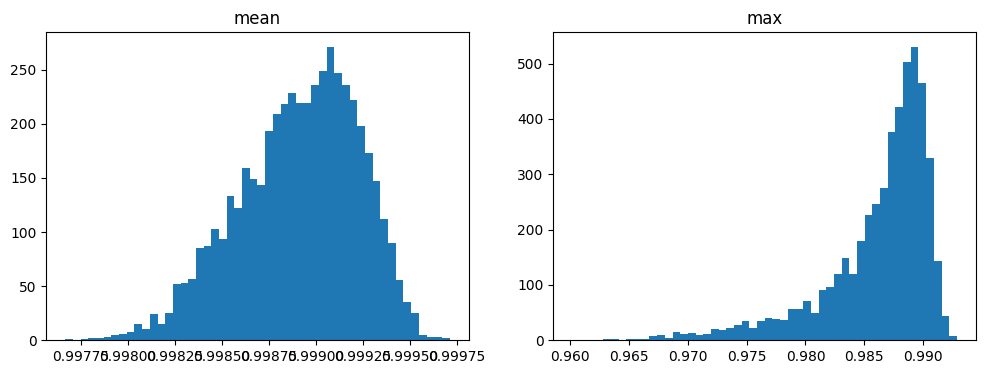

In [11]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

sample = df.sample(100, random_state=SEED)
sample_texts = sample["document"].tolist()

results = {}
for strategy in ["mean", "max"]:
    emb = embed_documents(sample_texts, pooling=strategy, batch_size=16)
    sims = cosine_similarity(emb)
    pairwise = sims[np.triu_indices_from(sims, k=1)]
    results[strategy] = pairwise
    print(f"{strategy}: mean={pairwise.mean():.4f} std={pairwise.std():.4f} min={pairwise.min():.4f} max={pairwise.max():.4f}")

fig, axes = plt.subplots(1, len(results), figsize=(12, 4))
for ax, (strategy, pairwise) in zip(axes, results.items()):
    ax.hist(pairwise, bins=50)
    ax.set_title(strategy)
plt.show()

In [12]:
# Embedding separation score per pooling strategy: 1 - mean(pairwise cosine similarity)
# Higher score = embeddings spread distinct articles further apart (more discriminative for clustering)
print(f"Embedding model: {model_name}")
for strategy, pairwise in results.items():
    separation_score = 1 - pairwise.mean()
    print(f"  {strategy:>5} pooling -> separation_score={separation_score:.4f}  (mean_sim={pairwise.mean():.4f}, std={pairwise.std():.4f})")

best_strategy = max(results, key=lambda s: 1 - results[s].mean())
print(f"\nBest pooling strategy by separation score: {best_strategy}")

Embedding model: xlm-roberta-large
   mean pooling -> separation_score=0.0011  (mean_sim=0.9989, std=0.0003)
    max pooling -> separation_score=0.0139  (mean_sim=0.9861, std=0.0047)

Best pooling strategy by separation score: max


In [13]:
embeddings = embed_documents(df["document"].tolist(), pooling=best_strategy, batch_size=16)
df["embedding"] = list(embeddings)

X = np.vstack(df["embedding"].values)
print(X.shape)  # (num_articles, 1024)

(1999, 1024)


In [14]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,      # smallest group of articles to count as an "event" — 2 is permissive, tune this
    min_samples=1,           # lower = less conservative about noise
    metric="euclidean",      # valid since vectors are L2-normalized
    cluster_selection_method="eom",  # "excess of mass" — usually better than "leaf" for uneven cluster sizes
)

df["cluster_id"] = clusterer.fit_predict(X)

print(df["cluster_id"].value_counts().head(20))
print("Noise (unclustered) articles:", (df["cluster_id"] == -1).sum())
print("Number of clusters found:", df["cluster_id"].nunique() - (1 if -1 in df["cluster_id"].values else 0))

cluster_id
 1    1978
-1      17
 2       2
 0       2
Name: count, dtype: int64
Noise (unclustered) articles: 17
Number of clusters found: 3


In [15]:
# Clustering evaluation: unsupervised metrics on non-noise points
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

mask = df["cluster_id"] != -1
X_valid = X[mask.values]
labels_valid = df.loc[mask, "cluster_id"].values
n_clusters = len(set(labels_valid))
noise_ratio = 1 - mask.mean()

print(f"Model: {model_name} ({best_strategy} pooling) + HDBSCAN")
print(f"Articles: {len(df)} | Clusters (excl. noise): {n_clusters} | Noise ratio: {noise_ratio:.2%}")

if n_clusters > 1:
    sil = silhouette_score(X_valid, labels_valid, metric="cosine")
    dbi = davies_bouldin_score(X_valid, labels_valid)
    ch = calinski_harabasz_score(X_valid, labels_valid)
    print(f"Silhouette Score (cosine): {sil:.4f}")
    print(f"Davies-Bouldin Index:      {dbi:.4f}  (lower is better)")
    print(f"Calinski-Harabasz Index:   {ch:.2f}  (higher is better)")
else:
    sil = dbi = ch = float("nan")
    print("Not enough clusters to compute silhouette/DBI/CH.")

# Save scores so they can be compared against the other embedding models later
scores_path = RESULTS_DIR / "xlmr_large_scores.csv"
row = {
    "model": model_name,
    "pooling": best_strategy,
    "embedding_dim": X.shape[1],
    "separation_score": round(1 - results[best_strategy].mean(), 4),
    "n_articles": len(df),
    "n_clusters": n_clusters,
    "noise_ratio": round(noise_ratio, 4),
    "silhouette": round(sil, 4) if n_clusters > 1 else None,
    "davies_bouldin": round(dbi, 4) if n_clusters > 1 else None,
    "calinski_harabasz": round(ch, 2) if n_clusters > 1 else None,
}
pd.DataFrame([row]).to_csv(scores_path, index=False)
print(f"Saved scores to {scores_path}")

Model: xlm-roberta-large (max pooling) + HDBSCAN
Articles: 1999 | Clusters (excl. noise): 3 | Noise ratio: 0.85%
Silhouette Score (cosine): 0.2352
Davies-Bouldin Index:      1.1711  (lower is better)
Calinski-Harabasz Index:   3.91  (higher is better)
Saved scores to /kaggle/working/results/xlmr_large/xlmr_large_scores.csv
